
Protein ID : QHR63260.2
Protein Length : 1273

========== PREDICTED EPITOPES ==========

16-23 | Score=-1.40 | NLTTRTQ
18-25 | Score=-1.13 | TTRTQLP
19-26 | Score=-1.26 | TRTQLPP
24-31 | Score=-1.10 | PPAYTNS
27-34 | Score=-1.24 | YTNSFTR
28-35 | Score=-1.11 | TNSFTRG
33-40 | Score=-1.20 | RGVYYPD
34-41 | Score=-1.11 | GVYYPDK
37-44 | Score=-1.11 | YPDKVFR
38-45 | Score=-1.04 | PDKVFRS
70-77 | Score=-1.49 | SGTNGTK
71-78 | Score=-2.01 | GTNGTKR
72-79 | Score=-1.56 | TNGTKRF
73-80 | Score=-1.96 | NGTKRFD
74-81 | Score=-1.96 | GTKRFDN
75-82 | Score=-2.13 | TKRFDNP
76-83 | Score=-1.43 | KRFDNPV
92-99 | Score=-1.63 | ASTEKSN
93-100 | Score=-1.24 | STEKSNI
95-102 | Score=-1.03 | EKSNIIR
108-115 | Score=-1.33 | TLDSKTQ
109-116 | Score=-1.34 | LDSKTQS
110-117 | Score=-1.34 | DSKTQSL
141-148 | Score=-1.34 | GVYYHKN
142-149 | Score=-1.79 | VYYHKNN
143-150 | Score=-2.94 | YYHKNNK
144-151 | Score=-2.87 | YHKNNKS
145-152 | Score=-2.81 | HKNNKSW
146-153 | Score=-2.09 | KNNKSWM
147-154 | Score=-2.0

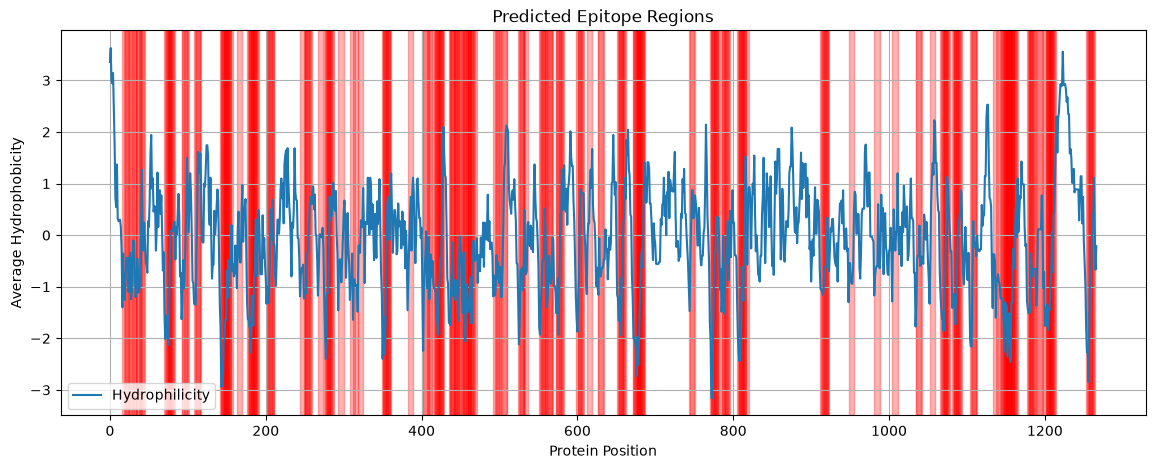

In [2]:


from Bio import Entrez
from Bio import SeqIO
import matplotlib.pyplot as plt



Entrez.email = "navaneethsundar2007@gmail.com

accession = "QHR63260.2

def load_sequence():

    handle = Entrez.efetch(
        db="protein",
        id=accession,
        rettype="fasta",
        retmode="text"
    )

    record = SeqIO.read(handle, "fasta")
    handle.close()

    return str(record.seq), record.id




hydro_scale = {

'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,
'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,
'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,
'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,
'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2

}




def compute_scores(seq, window=7):

    scores=[]

    for i in range(len(seq)-window+1):

        fragment=seq[i:i+window]

        score=sum(hydro_scale[a] for a in fragment)/window

        scores.append(score)

    return scores




def predict_epitopes(scores, seq, threshold=-1.0, window=7):

    epitopes=[]

    for i,score in enumerate(scores):

        if score<=threshold:

            epitopes.append((i,i+window,score))

    return epitopes




def plot_scores(scores, epitopes):

    plt.figure(figsize=(14,5))

    plt.plot(scores,label="Hydrophilicity")

    for start,end,score in epitopes:

        plt.axvspan(start,end,color="red",alpha=0.3)

    plt.title("Predicted Epitope Regions")

    plt.xlabel("Protein Position")

    plt.ylabel("Average Hydrophobicity")

    plt.grid(True)

    plt.legend()

    plt.show()




def main():

    seq,protein_id=load_sequence()

    print("\nProtein ID :",protein_id)

    print("Protein Length :",len(seq))

    window=7

    scores=compute_scores(seq,window)

    epitopes=predict_epitopes(scores,seq,-1.0,window)

    print("\n========== PREDICTED EPITOPES ==========\n")

    for start,end,score in epitopes:

        print(f"{start}-{end} | Score={score:.2f} | {seq[start:end]}")

    plot_scores(scores,epitopes)


if __name__=="__main__":

    main()